**1-SetUps**

In [92]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'e:\New folder\menna ahmed khamis\after iti\Ai\Jupyter_lab\projects\6-house_price_prediction\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [93]:
# install the required libraries
%pip install -q numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'e:\New folder\menna ahmed khamis\after iti\Ai\Jupyter_lab\projects\6-house_price_prediction\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [1]:
# importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.preprocessing import OneHotEncoder ,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GroupKFold, cross_validate




from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [95]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "housing.csv"          # update path for a different dataset


**2-Load Data**

In [96]:
df=pd.read_csv(CSV_PATH)

In [97]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


# California Housing Dataset — Column Description

| Column | Meaning | Example / Unit |
|---|---|---|
| **longitude** | The longitude coordinate of the housing area. It represents the east/west geographic position. | `-122.23` |
| **latitude** | The latitude coordinate of the housing area. It represents the north/south geographic position. | `37.88` |
| **housing_median_age** | The median age of houses in the area. | `41 years` |
| **total_rooms** | The total number of rooms in all houses within the area/block group. | `880 rooms` |
| **total_bedrooms** | The total number of bedrooms in all houses within the area/block group. | `129 bedrooms` |
| **population** | The total number of people living in the area/block group. | `322 people` |
| **households** | The total number of households in the area. A household is a group of people living together in a housing unit. | `126 households` |
| **median_income** | The median household income in the area. The value is represented in units of **$10,000**. | `3.5` ≈ `$35,000` |
| **median_house_value** | The median value (price) of houses in the area. This is usually the **target variable** for house price prediction. | `$452,600` |
| **ocean_proximity** | A categorical feature describing how close the area is to the ocean. | `INLAND`, `NEAR OCEAN` |

## Machine Learning Target

For a **House Price Prediction** problem:

### Features (X)
- `longitude`
- `latitude`
- `housing_median_age`
- `total_rooms`
- `total_bedrooms`
- `population`
- `households`
- `median_income`
- `ocean_proximity`

### Target (y)
- `median_house_value`



In [98]:
df.shape

(20640, 10)

**3. Exploratory Data Analysis (EDA)**

In [99]:
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
categorical_cols = ['ocean_proximity']

In [100]:
df[categorical_cols].value_counts()

ocean_proximity
<1H OCEAN          9136
INLAND             6551
NEAR OCEAN         2658
NEAR BAY           2290
ISLAND                5
Name: count, dtype: int64

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [102]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)


Number of duplicate rows: 0


In [103]:
constant_features = [col for col in df.columns if df[col].nunique() == 1]

print("Constant Features:", constant_features)
print("Number of Constant Features:", len(constant_features))

threshold = 0.95

quasi_constant_features = []

for col in df.columns[:-1]:  # exclude the target column
    top_frequency = df[col].value_counts(normalize=True).iloc[0]
    if top_frequency >= threshold:
        quasi_constant_features.append(col)

print("Quasi-Constant Features:", quasi_constant_features)
print("Number of Quasi-Constant Features:", len(quasi_constant_features))

Constant Features: []
Number of Constant Features: 0
Quasi-Constant Features: []
Number of Quasi-Constant Features: 0


In [104]:
zero_percentage = (df.iloc[:, :-1] == 0).mean() * 100

zero_percentage.sort_values(ascending=False)

longitude            0.000
latitude             0.000
housing_median_age   0.000
total_rooms          0.000
total_bedrooms       0.000
population           0.000
households           0.000
median_income        0.000
median_house_value   0.000
dtype: float64

In [105]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000


## Key EDA Insights

- **Missing values:** `total_bedrooms` has **207 missing values** because its count is 20,433 instead of 20,640.

- **Total Rooms:** The mean (2635.76) is noticeably higher than the median (2127), and the maximum (39,320) is much larger than Q3 (3,148), suggesting **right skewness and potential extreme values**.

- **Total Bedrooms:** The mean (537.87) is higher than the median (435), while the maximum (6,445) is much larger than Q3 (647), suggesting **right skewness and potential extreme values**. It also contains missing values.

- **Population & Households:** Both have means higher than their medians and maximum values much larger than Q3, suggesting **right-skewed distributions with potential extreme values**.

- **Median Income:** The mean (3.87) is slightly higher than the median (3.53), suggesting **mild right skewness**. The values are scaled rather than representing raw dollar amounts.

- **Median House Value:** The mean (206,855) is higher than the median (179,700), suggesting **right skewness**. The maximum value is exactly **500,001**, indicating that the target variable is capped at this value.


In [106]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

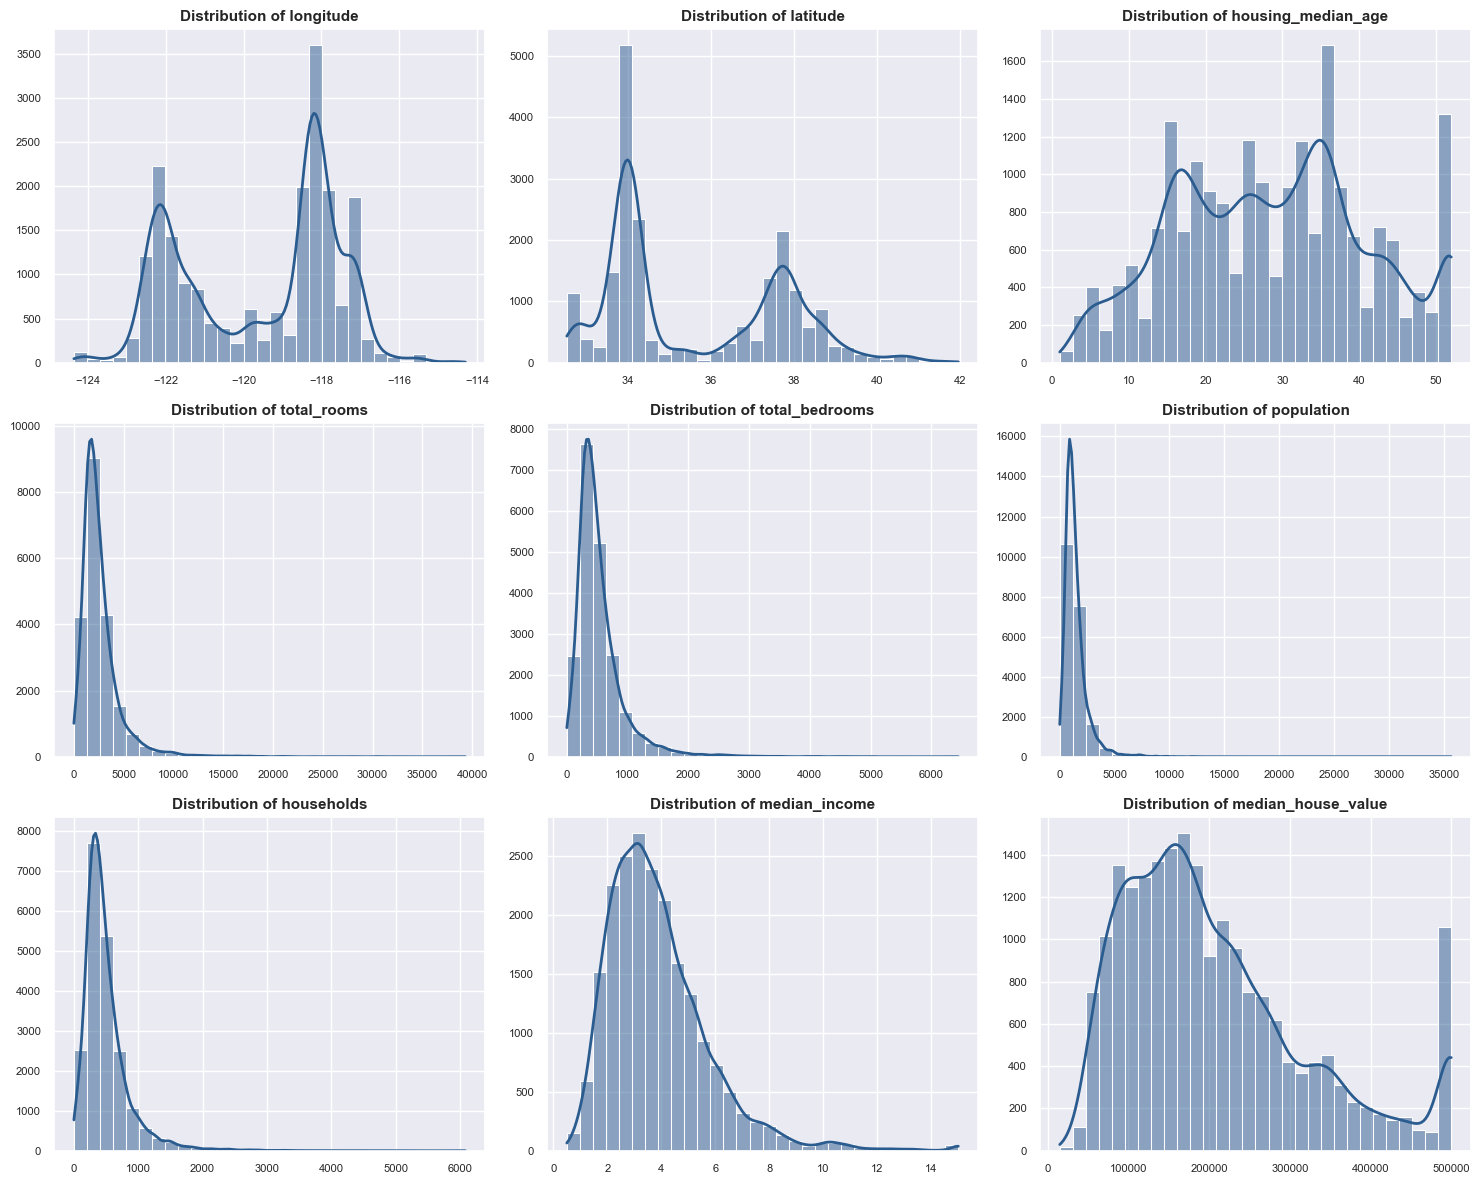

In [107]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i],
        color="#2b5c8f",
        bins=30,
        line_kws={"linewidth": 2},
    )
    axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

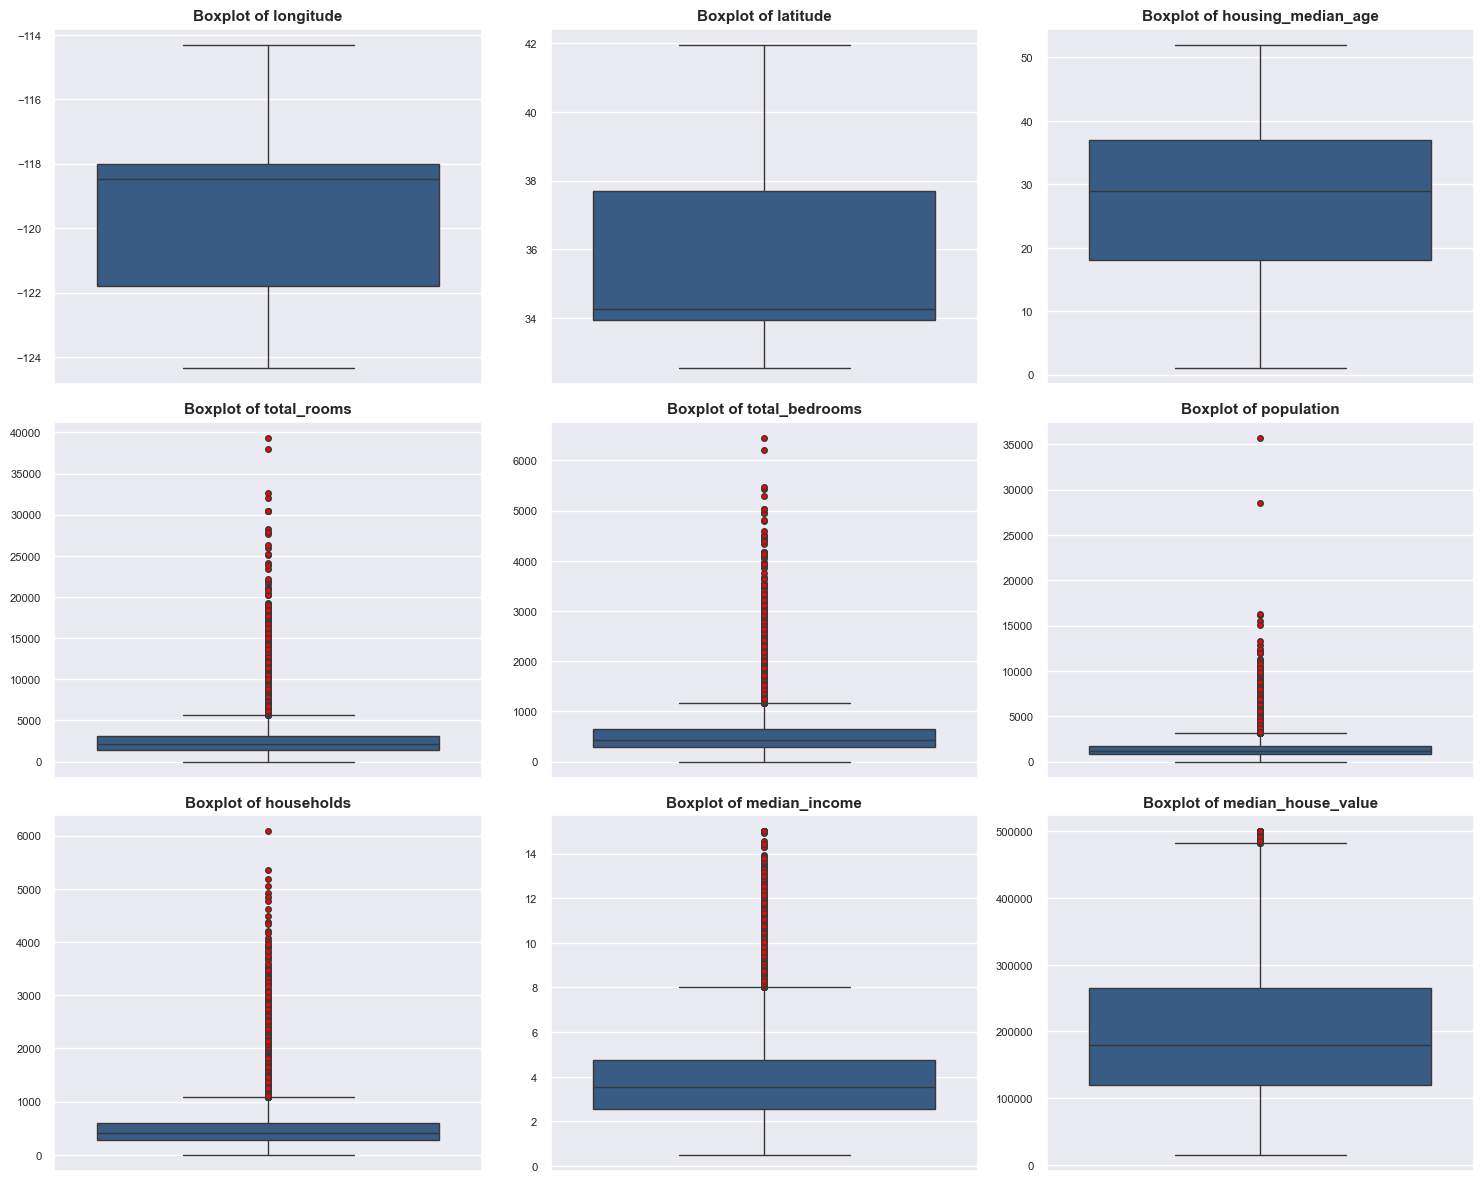

In [108]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        color="#2b5c8f",
        flierprops={"markerfacecolor": "red", "markersize": 4},  
    )
    axes[i].set_title(f"Boxplot of {col}", fontsize=11, fontweight="bold")
    axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [109]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\n--- {col} ---")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))
    print("Percentage:", len(outliers) / len(df) * 100)


--- longitude ---
Q1: -121.8
Q3: -118.01
IQR: 3.789999999999992
Lower bound: -127.48499999999999
Upper bound: -112.32500000000002
Number of outliers: 0
Percentage: 0.0

--- latitude ---
Q1: 33.93
Q3: 37.71
IQR: 3.780000000000001
Lower bound: 28.259999999999998
Upper bound: 43.38
Number of outliers: 0
Percentage: 0.0

--- housing_median_age ---
Q1: 18.0
Q3: 37.0
IQR: 19.0
Lower bound: -10.5
Upper bound: 65.5
Number of outliers: 0
Percentage: 0.0

--- total_rooms ---
Q1: 1447.75
Q3: 3148.0
IQR: 1700.25
Lower bound: -1102.625
Upper bound: 5698.375
Number of outliers: 1287
Percentage: 6.2354651162790695

--- total_bedrooms ---
Q1: 296.0
Q3: 647.0
IQR: 351.0
Lower bound: -230.5
Upper bound: 1173.5
Number of outliers: 1271
Percentage: 6.157945736434108

--- population ---
Q1: 787.0
Q3: 1725.0
IQR: 938.0
Lower bound: -620.0
Upper bound: 3132.0
Number of outliers: 1196
Percentage: 5.794573643410852

--- households ---
Q1: 280.0
Q3: 605.0
IQR: 325.0
Lower bound: -207.5
Upper bound: 1092.5
Numb

The IQR method identifies around 3–6% of observations as statistical outliers in some features. These are not necessarily errors and should not be removed automatically. Most of them are concentrated in right-skewed features such as rooms, bedrooms, population, and households.

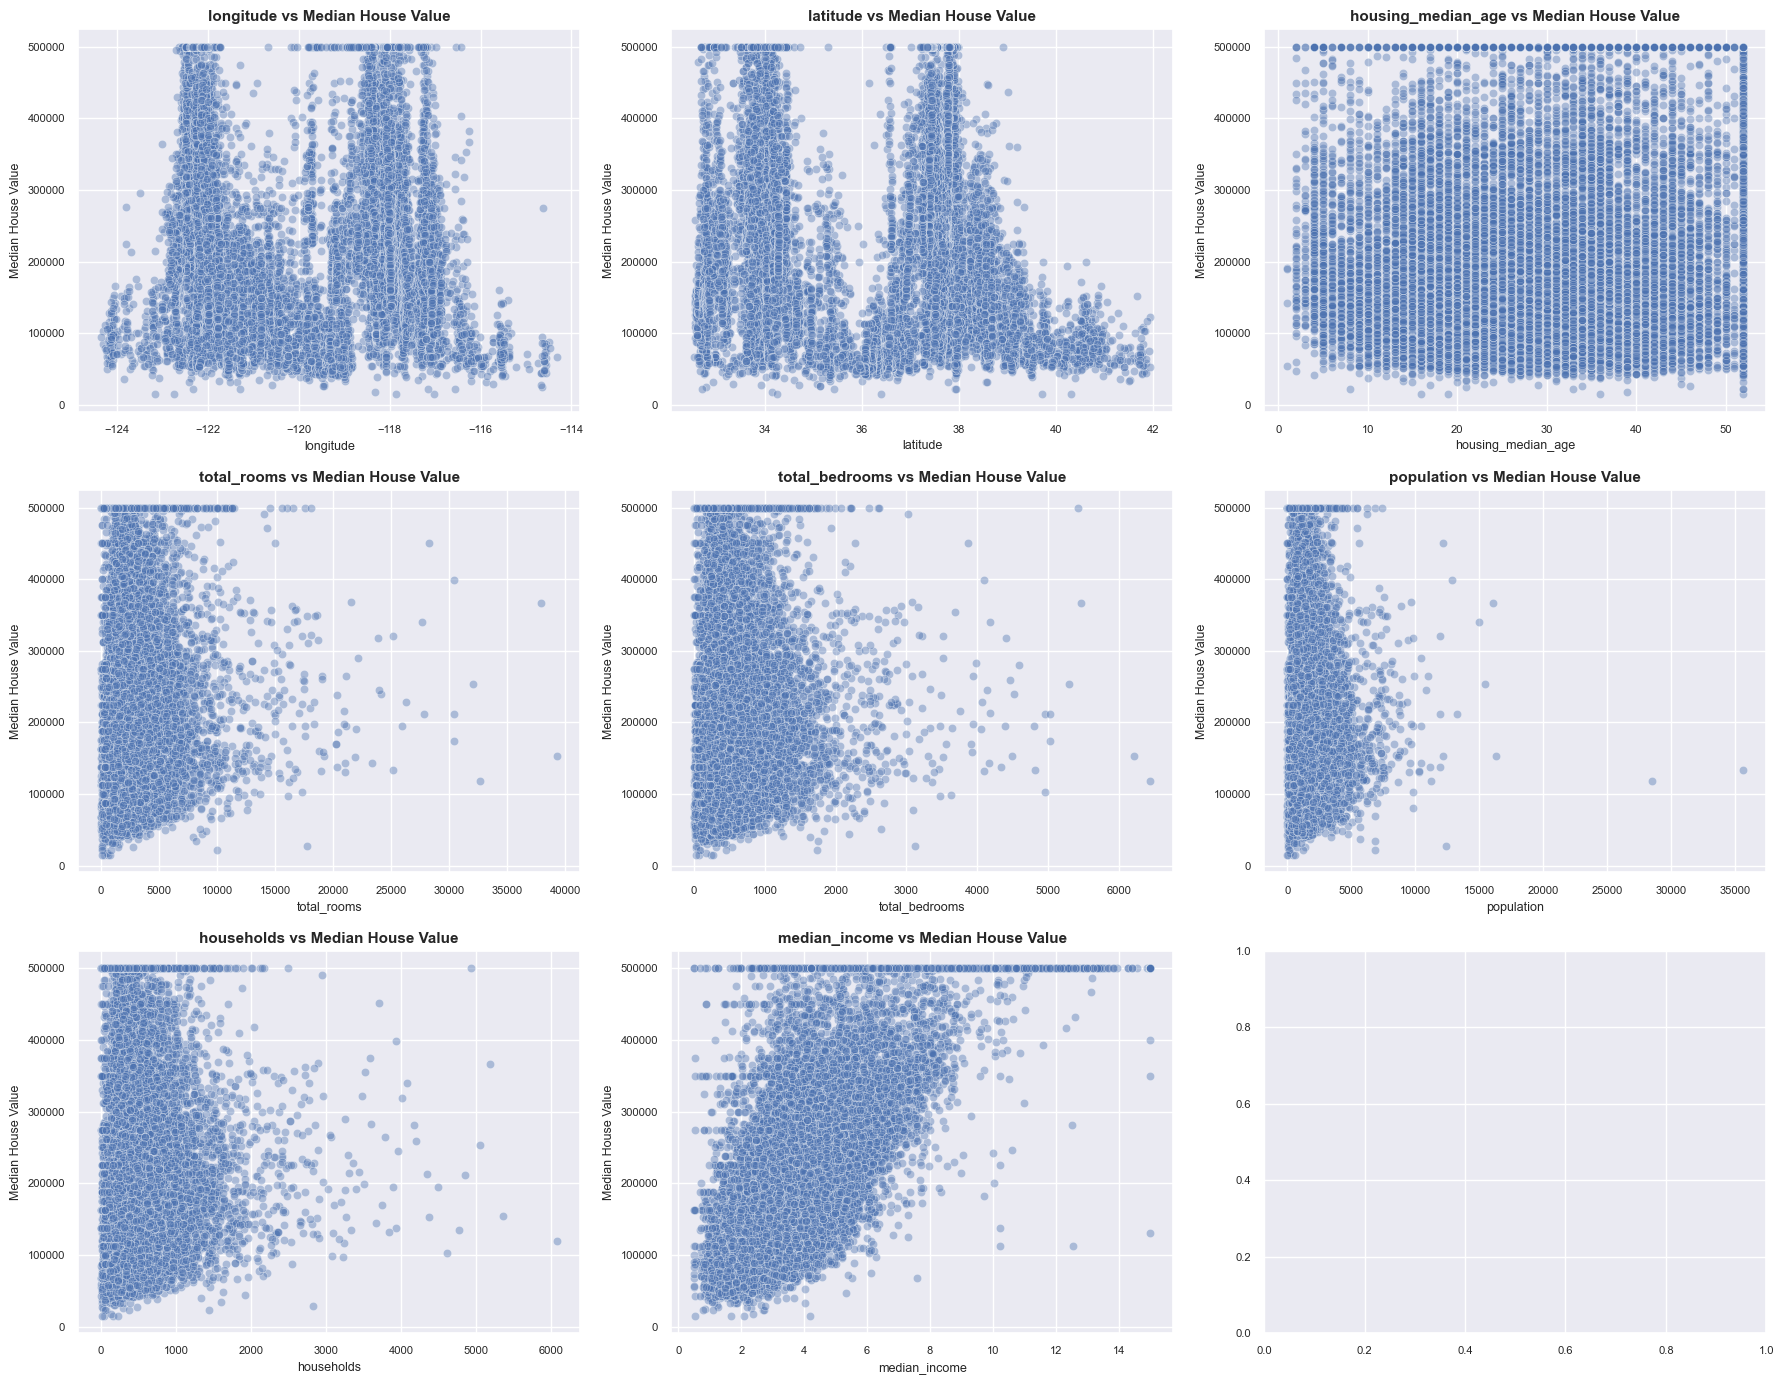

In [110]:

# Exclude the target
features = numeric_cols.drop("median_house_value")

# Create 3x3 grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 14))

# Flatten axes so we can loop through them easily
axes = axes.flatten()

for i, col in enumerate(features):
    sns.scatterplot(
        data=df,
        x=col,
        y="median_house_value",
        ax=axes[i],
        alpha=0.4
    )

    axes[i].set_title(
        f"{col} vs Median House Value",
        fontsize=11,
        fontweight="bold"
    )

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Median House Value")

plt.tight_layout()
plt.show()

Most features show weak or scattered relationships with the target, while median_income shows the clearest positive linear relationship. longitude and latitude may have non-linear relationships with the target due to geographical patterns.

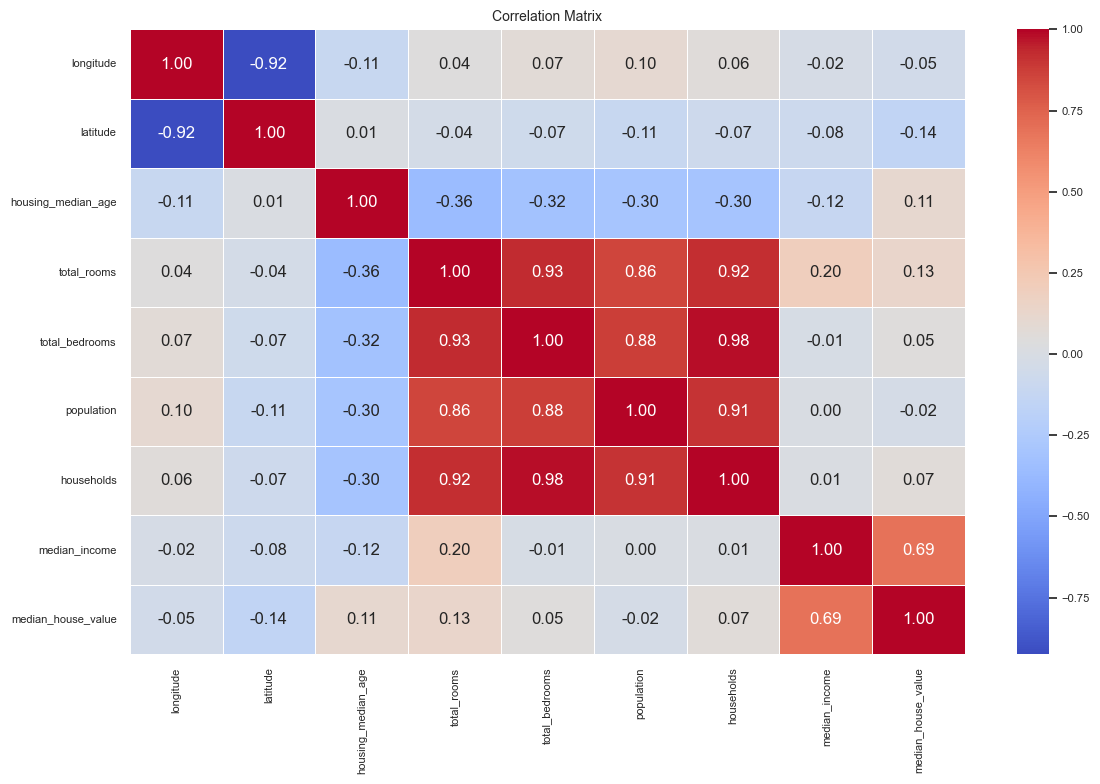

In [111]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Correlation Analysis

- `longitude` and `latitude` have a **strong negative correlation (-0.92)**.
- `total_rooms`, `total_bedrooms`, `population`, and `households` have **strong positive correlations** with each other, especially `total_bedrooms` and `households` (**0.98**).
- `median_income` has the **strongest correlation with the target `median_house_value` (0.69)**, making it an important feature for prediction.
- The highly correlated features may indicate **redundant information / multicollinearity**, especially for linear models.


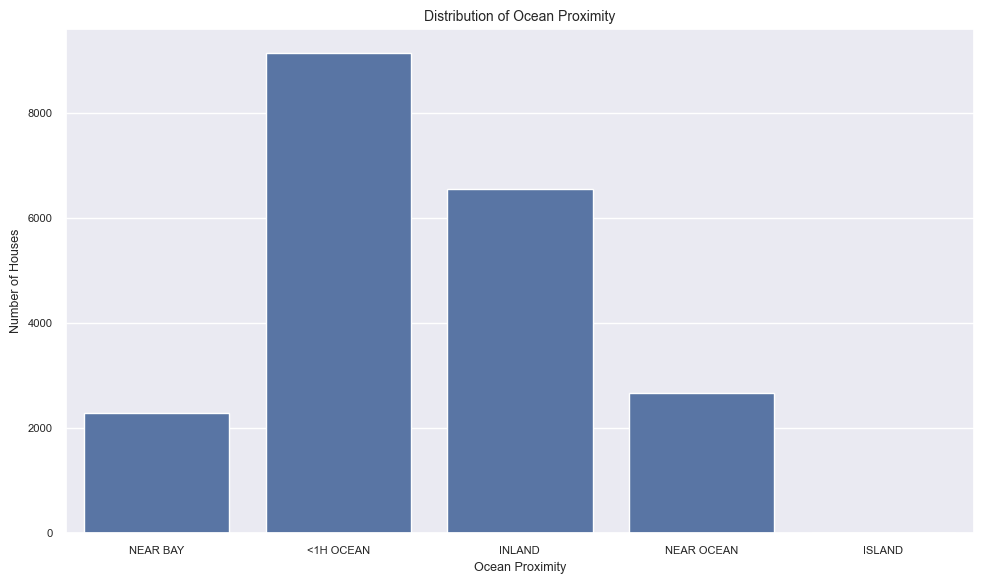

In [112]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="ocean_proximity"
)

plt.title("Distribution of Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Number of Houses")

plt.tight_layout()
plt.show()

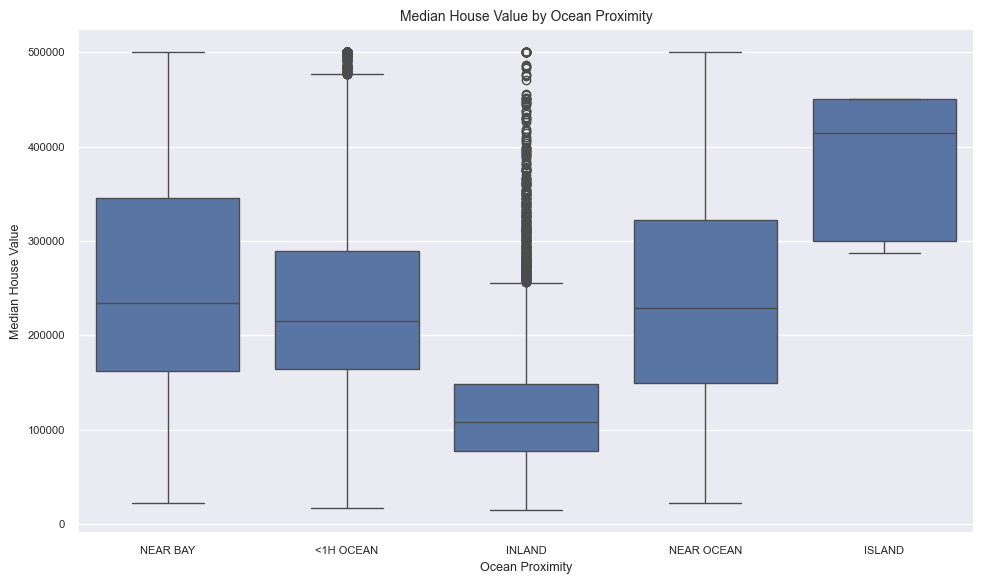

In [113]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="ocean_proximity",
    y="median_house_value"
)

plt.title("Median House Value by Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Median House Value")

plt.tight_layout()
plt.show()

### Ocean Proximity Insights

- `ISLAND` has the highest median house value.
- `INLAND` has the lowest median.
- House values differ clearly across categories.
- This suggests `ocean_proximity` is a useful feature.
- Potential outliers are visible, especially in `INLAND` and `<1H OCEAN`.

In [114]:
df.groupby("ocean_proximity")["median_house_value"].mean()

ocean_proximity
<1H OCEAN    240084.285
INLAND       124805.392
ISLAND       380440.000
NEAR BAY     259212.312
NEAR OCEAN   249433.977
Name: median_house_value, dtype: float64

In [115]:
(df["median_house_value"] == 500001).sum()

np.int64(965)

## Key EDA Findings & Things to Consider

- **Categorical Feature:** `ocean_proximity` needs to be **encoded** before using it in most ML models.
- **Missing Values:** `total_bedrooms` contains **207 missing values** and needs to be handled.
- **Skewness & Outliers:** Several features (`total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`) show **right skewness and potential outliers**. Treatment depends on the chosen model and should not be done automatically.
- **High Feature Correlation:** Some features are highly correlated, especially `total_bedrooms` ↔ `households` (**0.98**) and `total_rooms` ↔ `total_bedrooms` (**0.93**). We should investigate possible redundancy/multicollinearity before dropping anything.
- **Geographical Features:** `longitude` and `latitude` show a strong correlation, but their relationship with house value may be **non-linear**, so they should not be dropped automatically.
- **Target Relationship:** `median_income` has the strongest linear relationship with `median_house_value` (**0.69**) and appears to be an important predictive feature.
- **Ocean Proximity:** `ocean_proximity` shows a clear relationship with house value, so it may provide useful information for prediction.
- **Next Step:** Final decisions about **outliers, correlated features, and feature selection** should be made after considering the chosen model and validation performance.

In [116]:
target="median_house_value"

In [117]:
y=df[target]
x=df.drop(columns=[target])

In [118]:
x[:5]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY


In [119]:
y[:5]

0   452600.000
1   358500.000
2   352100.000
3   341300.000
4   342200.000
Name: median_house_value, dtype: float64

**spliting data**

In [120]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [121]:
x[:5]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY


**4. Data Preprocessing**

In [122]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

# numerical features - preprocessing steps
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps=[
        # ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numerical features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features: ['ocean_proximity']


**BaseModel**

In [123]:
baseline_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

baseline_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [124]:
y_pred_train = baseline_model.predict(X_train)

mae = mean_absolute_error(y_train, y_pred_train)
mse = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred_train)

print("Test MAE:", mae)
print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test R²:", r2)

Test MAE: 49594.84209472437
Test MSE: 4683203783.504253
Test RMSE: 68433.93736666226
Test R²: 0.6496648627123223


In [125]:
y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test R²:", r2)

Test MAE: 50670.48923565362
Test MSE: 4908290571.346432
Test RMSE: 70059.19333925014
Test R²: 0.6254382675296266


In [126]:
from sklearn.ensemble import HistGradientBoostingRegressor

models = [
    ("Linear Regression", LinearRegression()),
    
    ("Decision Tree", DecisionTreeRegressor(
        random_state=42
    )),
    
    ("Random Forest", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )),
    
    ("Gradient Boosting", GradientBoostingRegressor(
        random_state=42
    )),
    
    ("HistGB", HistGradientBoostingRegressor(
        random_state=42
    )),
    
    ("XGBoost", XGBRegressor(
        random_state=42,
        n_jobs=-1
    ))
]

In [127]:
k=5
cv=KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [128]:
results = []

for name, model in models:

    model_pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error"
        },
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "CV R²": scores["test_r2"].mean(),
        "CV MAE": -scores["test_mae"].mean(),
        "CV RMSE": -scores["test_rmse"].mean()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by R²: higher is better
results_df = results_df.sort_values(
    by="CV R²",
    ascending=False
).reset_index(drop=True)

print(results_df)

               Model  CV R²    CV MAE   CV RMSE
0            XGBoost  0.827 32011.683 48148.128
1             HistGB  0.826 32353.191 48277.371
2      Random Forest  0.817 32328.533 49445.286
3  Gradient Boosting  0.773 38406.835 55127.963
4  Linear Regression  0.648 49667.159 68604.163
5      Decision Tree  0.632 44430.282 70085.788


In [129]:
XGBRegressor_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", XGBRegressor(random_state=RANDOM_STATE))
    ]
)

**7. Hyperparameter Tuning**

In [130]:
param_distributions = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

In [131]:
random_search = RandomizedSearchCV(
    estimator=XGBRegressor_pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.8, 0.9, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [132]:
y_train_pred = random_search.predict(X_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print("Train MAE:", train_mae)
print("Train RMSE:", train_rmse)
print("Train R²:", train_r2)

Train MAE: 13124.899673461914
Train RMSE: 18514.137371598044
Train R²: 0.9743582533294313


In [133]:
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test R²:", r2)

Test MAE: 29730.388522835667
Test MSE: 2046387079.8220394
Test RMSE: 45237.01006722305
Test R²: 0.8438359997678648


In [134]:
print(random_search.best_params_)

{'model__subsample': 1.0, 'model__n_estimators': 700, 'model__min_child_weight': 1, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}


In [135]:
final_model = Pipeline([
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        subsample=1.0,
        n_estimators=700,
        min_child_weight=1,
        max_depth=6,
        learning_rate=0.1,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

In [136]:
final_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [137]:
# Predictions
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)

# Train metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("=== Train Performance ===")
print("Train MAE:", train_mae)
print("Train MSE:", train_mse)
print("Train RMSE:", train_rmse)
print("Train R²:", train_r2)

print("\n=== Test Performance ===")
print("Test MAE:", test_mae)
print("Test MSE:", test_mse)
print("Test RMSE:", test_rmse)

print("Test R²:", test_r2)

=== Train Performance ===
Train MAE: 13124.899673461914
Train MSE: 342773282.61440337
Train RMSE: 18514.137371598044
Train R²: 0.9743582533294313

=== Test Performance ===
Test MAE: 29730.388522835667
Test MSE: 2046387079.8220394
Test RMSE: 45237.01006722305
Test R²: 0.8438359997678648


**Feature Eng**

## Feature Engineering

Several ratio-based features were explored:

- `rooms_per_household`
- `bedrooms_per_room`
- `population_per_household`

The engineered features were evaluated using 5-fold cross-validation.
They did not provide a meaningful improvement in CV performance compared
with the original feature set, so they were not included in the final model.

In [138]:
# ============================================================
# Error Analysis
# ============================================================

# Create results DataFrame
results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_test_pred
})

# Calculate errors
results["error"] = results["actual"] - results["predicted"]

results["absolute_error"] = results["error"].abs()

results["percentage_error"] = (
    results["absolute_error"] / results["actual"]
) * 100


# ============================================================
# 1. Error by Price Range
# ============================================================

results["price_range"] = pd.cut(
    results["actual"],
    bins=[0, 150000, 300000, 400000, 500001],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

price_error = results.groupby(
    "price_range",
    observed=True
).agg(
    Mean_Absolute_Error=("absolute_error", "mean"),
    Median_Absolute_Error=("absolute_error", "median"),
    Mean_Percentage_Error=("percentage_error", "mean"),
    Number_of_Samples=("absolute_error", "count")
)

print("=== Error Analysis by Price Range ===")
print(price_error)


# ============================================================
# 2. Error by Ocean Proximity
# ============================================================

results["ocean_proximity"] = X_test["ocean_proximity"].values

location_error = results.groupby(
    "ocean_proximity"
).agg(
    Mean_Absolute_Error=("absolute_error", "mean"),
    Median_Absolute_Error=("absolute_error", "median"),
    Mean_Percentage_Error=("percentage_error", "mean"),
    Number_of_Samples=("absolute_error", "count")
).sort_values(
    "Mean_Absolute_Error",
    ascending=False
)

print("\n=== Error Analysis by Ocean Proximity ===")
print(location_error)


# ============================================================
# 3. Overall Error Summary
# ============================================================

print("\n=== Overall Error Summary ===")

print("Mean Absolute Error:",
      results["absolute_error"].mean())

print("Median Absolute Error:",
      results["absolute_error"].median())

print("Maximum Absolute Error:",
      results["absolute_error"].max())

print("Mean Percentage Error:",
      results["percentage_error"].mean())

=== Error Analysis by Price Range ===
             Mean_Absolute_Error  Median_Absolute_Error  \
price_range                                               
Low                    20307.903              13981.402   
Medium                 27625.172              20484.688   
High                   45384.593              36180.500   
Very High              64399.308              43645.375   

             Mean_Percentage_Error  Number_of_Samples  
price_range                                            
Low                         22.937               1516  
Medium                      13.212               1861  
High                        13.053                412  
Very High                   13.630                339  

=== Error Analysis by Ocean Proximity ===
                 Mean_Absolute_Error  Median_Absolute_Error  \
ocean_proximity                                               
ISLAND                    112514.094             112514.094   
NEAR OCEAN                 36477.637   

In [ ]:
# Create geographic groups based on latitude and longitude
X_train_spatial = X_train.copy()

X_train_spatial["geo_group"] = (
    X_train_spatial["latitude"].round(1).astype(str)
    + "_"
    + X_train_spatial["longitude"].round(1).astype(str)
)

groups = X_train_spatial["geo_group"]

print("Number of geographic groups:", groups.nunique())

Number of geographic groups: 1417


In [140]:
spatial_cv = GroupKFold(n_splits=5)

spatial_scores = cross_validate(
    best_xgb,
    X_train,
    y_train,
    groups=groups,
    cv=spatial_cv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"
    },
    n_jobs=-1
)

print("=== Spatial CV Performance ===")

print("Spatial CV R²:",
      spatial_scores["test_r2"].mean())

print("Spatial CV MAE:",
      -spatial_scores["test_mae"].mean())

print("Spatial CV RMSE:",
      -spatial_scores["test_rmse"].mean())

=== Spatial CV Performance ===
Spatial CV R²: 0.7941113944693674
Spatial CV MAE: 35662.82261442244
Spatial CV RMSE: 52283.42861610088
